#### Name: Kristen Townsend

# PHYS 230 Lab Assignment 13

### Monday, March 9, 2026: Chapter 6, sections 3.5 - 3.8
- Nonlinear equations - Newton's Method 

In [4]:
# put all import statements here
import numpy as np
import matplotlib.pyplot as plt


## Newton's Method - single variable (22 pts)

Solve the same problem from class used for binary search, but analyzed using Newton's Method instead. 
Find the roots of $$ f(x) = e^{x-\sqrt{x}}-x$$

To do this: 

1) Take the derivative by hand. You can use something like WolframAlpha to check your derivative. Write it in markdown. 

2) Write two functions - `f(x)` that returns the result of the function for a given $x$ value and `df(x)` one that returns the derivative. 

3) Make a plot of the function from $x=0$ to $x=5$. Use this to estimate the roots. 

4) Apply the functions to find both roots. 

*You must clearly comment your code and include a markdown cell explaining your process*

The derivative is: 

$$e^{x-\sqrt{x}}\left(1-\frac{1}{2\sqrt{x}}\right)-1 $$

part 1\
derivative to function above:

$e^{x-\sqrt{x}}\left(1-\frac{1}{2\sqrt{x}}\right)-1 $

In [2]:
# part 2
def f(x):
    return np.exp(x - x**(0.5)) - x

def df(x):
    return np.exp(x - x**(0.5)) * (1 - (1 / (2*x**0.5))) - 1

I imported numpy above for the exp() function needed when defining the functions f(x) and df(x)

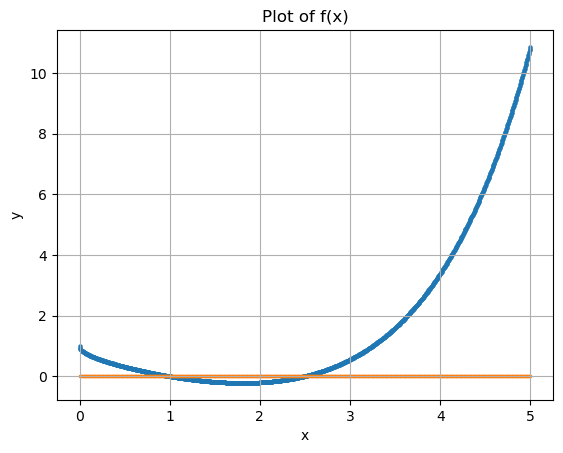

In [6]:
# part 3
x_vals = np.linspace(0, 5, 1000)
y_vals = f(x_vals)
y_zero = np.zeros(1000)

plt.scatter(x_vals, y_vals, s=5)
plt.grid()
plt.scatter(x_vals, y_zero, s=2)

plt.title("Plot of f(x)")
plt.ylabel("y")
plt.xlabel("x")

plt.show()

I made an array of x values and an array of y values using the function f(x) defined above the then make the plot showing the functions motion.\
I imported matplotlib.pyplot above to make the plot be a plot.\
I used the scatter() function because I like it more than plot(). There isn't really any deep reasoning there.

From the graph, I can estimate roots to be located at x = 1 and x = 2.5.

In [24]:
# part 4
x_guess = np.array([1.0, 2.5])
x_0 = np.copy(x_guess)

# define desired accuracy
accuracy = 1e-11

# apply newton's method
err = 1.0
while err > accuracy:
    delta = f(x_guess) / df(x_guess)
    x_guess -= delta
    err = max(np.abs(delta))

print("Solutions:", x_guess)
print("Initial guesses:", x_0)

Solutions: [1.         2.49090932]
Initial guesses: [1.  2.5]


Using Newton's method, I used the following equation within a while loop:\
$x' = x - \Delta x = x - \frac{f(x)}{f'(x)}$\
The x_guess value is continuously updated with the ratio between f(x) and df(x) at the previous x_guess value.\
The while loop continues until the value reaches below desired accuracy.\
My guess was pretty close! The graph helps you not choose a bad section of the plot for an initial guess. If on the wrong side of a peak, it'll get stuck and never find the solution.

## Newton's Method - many variables (22 pts)
#### Adapted from Nonlinear Circuits (book exercise 6.18, pg. 276)

Exercise 6.1 used regular simultaneous equations to solve for the behavior of circuits of resistors.  Resistors are linear---current is proportional to voltage---and the resulting equations we need to solve are therefore also linear and can be solved by standard matrix methods.  Real circuits, however, often include nonlinear components.  To solve for the behavior of these circuits we need to solve nonlinear equations.

Consider the following simple circuit, a variation on the classic
Wheatstone bridge:

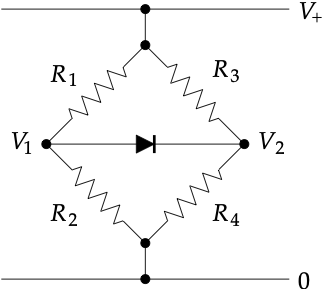

We will use Newton's Method to solve for the voltages in the 
The resistors obey the normal Ohm law, but the diode obeys the diode equation:
$$ I = I_0 (e^{V/V_T} - 1),$$
where $V$ is the voltage across the diode and $I_0$ and $V_T$ are constants.

The Kirchhoff current law says that the total net current flowing into or out of every point in a circuit must be zero.  Applying the law to voltage $V_1$ in the circuit above we get
$$
{V_1-V_+\over R_1} + {V_1\over R_2}
  + I_0\bigl[e^{(V_1-V_2)/V_T} - 1\bigr] = 0.
$$

   
1) In a markdown cell, derive the corresponding equation for voltage $V_2$.

2) Solve the two nonlinear equations for the voltages $V_1$ and $V_2$. 

3) Use Newton's method to solve the equations. This means you need to first take the derivatives of each equation with respect to each variable (so you'll have 4 equations). Define the Jacobian matrix. Setup the matrix necessary to analyze using the `np.linalg.solve()` function. Apply the following conditions: 

$$\begin{align*}
V_+ &= 5\,\textrm{V}, \\
R_1 &= 1\,\mathrm{k}\Omega, \qquad
R_2 = 4\,\mathrm{k}\Omega, \qquad
R_3 = 3\,\mathrm{k}\Omega, \qquad
R_4 = 2\,\mathrm{k}\Omega, \\
I_0 &= 3\,\textrm{nA},\qquad
V_T = 0.05\,\textrm{V}.
\end{align*}$$

4) Apply the function to find both roots to solve for $V_1$ and $V_2$. The electronic engineer's rule of thumb for diodes is that the voltage across a (forward biased) diode is always about 0.6 volts. Confirm that your results agree with this rule by taking the difference between your results.

*You must clearly comment your code and include a markdown cell explaining your process*

part 1\
Derive corresponding equation for voltage $V_2$:

$
{V_2-V_+\over R_3} + {V_2\over R_4} - I_0\bigl[e^{(V_1-V_2)/V_T} - 1\bigr] = 0.
$

I just focused on everything that intersected the junction at $V_2$ to find the eq using the Kirckhoff current law.

In [ ]:
# part 2
# ignore this one, same as part 3

In [19]:
# part 3
# defining equations
def circ1(V1,V2): # solved with V1
    a = (V1 - Vplus) / R1
    b = V1 / R2
    c = I0 * (np.exp((V1-V2)/VT) - 1)
    return a + b + c

def circ2(V1,V2): # solved with V2
    a = (V2 - Vplus) / R3
    b = V2 / R4
    c = I0 * (np.exp((V1-V2)/VT) - 1)
    return a + b - c

# partial derivatives
def dV1circ1(V1,V2):
    a = 1 / R1
    b = 1 / R2
    c = (I0 / VT) * np.exp((V1-V2)/VT)
    return a + b + c

def dV2circ1(V1,V2):
    c = (I0 / VT) * np.exp((V1-V2)/VT)
    return - c

def dV1circ2(V1,V2):
    c = (I0 / VT) * np.exp((V1-V2)/VT)
    return - c

def dV2circ2(V1,V2):
    a = 1 / R3
    b = 1 / R4
    c = (I0 / VT) * np.exp((V1-V2)/VT)
    return a + b + c


# define conditions
Vplus = 5 #volts
VT = 0.05 #volts

R1 = 1e3 #kilo-ohms
R2 = 4e3 #kilo-ohms
R3 = 3e3 #kilo-ohms
R4 = 2e3 #kilo-ohms

I0 = 3e-9 #nano-amps

# define accuracy
accuracy = 1e-10
# initial guess
V1 = 5.0
V2 = 4.0

# initial error
err = 10.0

while err > accuracy:
    # define Jacobian matrix
    # matrices to use linalg.solve() on
    A = np.array([[dV1circ1(V1,V2), dV2circ1(V1,V2)],
                  [dV1circ2(V1,V2), dV2circ2(V1,V2)]], float)
    v = np.array([circ1(V1,V2), circ2(V1,V2)], float)
    
    values = np.linalg.solve(A,v)
    # determine new values
    V1 -= values[0]
    V2 -= values[1]

    # calculate new error
    err = np.sqrt(values[0]**2 + values[1]**2)

# print results
print("V1:", V1, "V")
print("V2:", V2, "V")

V1: 3.4469546188585745 V
V2: 2.8295680717121385 V


When defining all of my functions I split up the equations to minimize mess-ups.

I need 4 derivatives:

Derivative for circ1 with respect to V1: $ {1\over R_1} + {1\over R_2} + {I_0\over V_T} e^{(V_1-V_2)/V_T} = 0 $

Derivative for circ1 with respect to V2: $ - {I_0\over V_T} e^{(V_1-V_2)/V_T} = 0 $

Derivative for circ2 with respect to V1: $ - {I_0\over V_T} e^{(V_1-V_2)/V_T} = 0 $

Derivative for circ2 with respect to V2: $ {1\over R_3} + {1\over R_4} + {I_0\over V_T} e^{(V_1-V_2)/V_T} = 0 $

I then defined the constant constraints given previously along with initial guesses for the values of V1, V2, and the initial error. I also defined my desired accuracy to be 1e-10.\
Within a while loop I set up a Jacobian matrix $A$ using the derivative functions defined above and the values within $v$ as the original functions found with Kirkhoff's rule as computed with the current values of V1 and V2.\
I then used linalg.solve() to compute the eigen values that susteined the relationship between A and v, which eventually became my solution if the error was smaller than the desired accuracy.

In [20]:
# part 4
# finding difference between the voltages
print("Voltage across diode:",np.abs(V1-V2), "V")

Voltage across diode: 0.6173865471464359 V


So it turns out it's best to do all the math in SI units.\
I just found the difference between the voltage found on either side of the diode.\
It does follow the engineer's rule!
